In [2]:
!pip install qiskit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 129.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 116.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 6.2 MB/s eta 0:00:00



Initial Quantum State
|ψ⟩ = α|0⟩ + β|1⟩
Enter α : 0.6
Enter β : 0.8

Enter Total Evolution Time : 100
Time Step (Δt) = 0.1
Enter Amplitude Damping Probability : 0.02
Enter Pure Dephasing Probability : 0.02

Initial Density Matrix:

[[0.36+0.j 0.48+0.j]
 [0.48+0.j 0.64+0.j]]

Number of Iterations = 1000

Final Density Matrix
[[9.99999999e-01+0.j 3.31401734e-14+0.j]
 [3.31401734e-14+0.j 1.07709911e-09+0.j]]

Final Bloch Vector
r_x = 0.000000
r_y = 0.000000
r_z = 1.000000


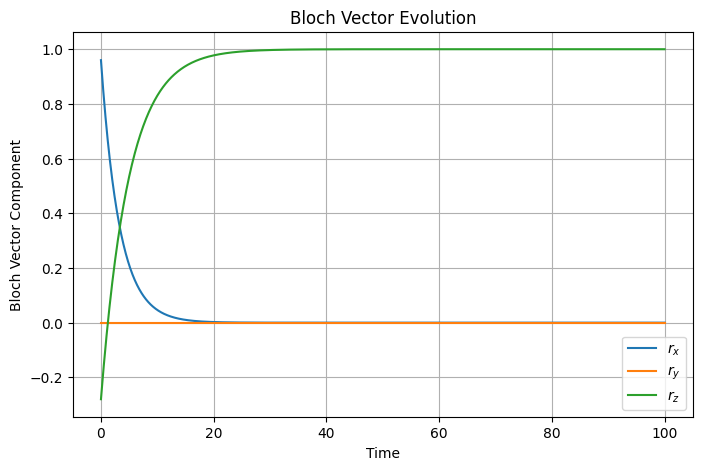

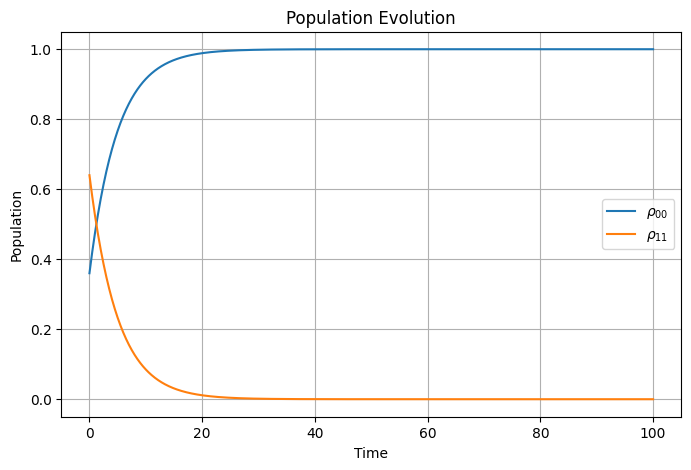

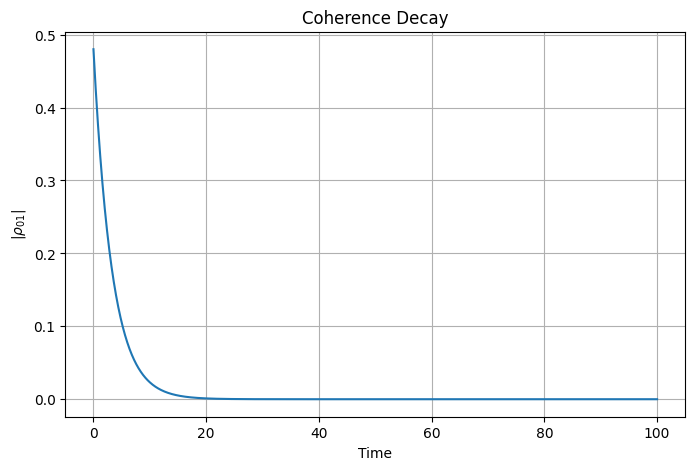

In [5]:
import numpy as np
import matplotlib.pyplot as plt

from qiskit.quantum_info import (
    Statevector,
    DensityMatrix,
    Kraus,
    Pauli
)

# taking user input for initial quantum state

print("\nInitial Quantum State")
print("|ψ⟩ = α|0⟩ + β|1⟩")

while True:
    alpha = complex(input("Enter α : "))
    beta  = complex(input("Enter β : "))

    norm = np.sqrt(abs(alpha)**2 + abs(beta)**2)

    if abs(norm - 1) < 1e-6:
        break

    print("State not normalized! Please enter again.\n")

# taking total evolution time as input
T = float(input("\nEnter Total Evolution Time : "))

# defining time step of krauss operator
dt = 0.1

print(f"Time Step (Δt) = {dt}")

# taking Noise probabilities (per time step) as input
p_amp = float(input("Enter Amplitude Damping Probability for  0.1  unit of time : "))
p_phase = float(input("Enter Pure Dephasing Probability  for  0.1  unit of time : "))


# DEFINING INITIAL STATE


psi = Statevector([alpha, beta])

rho = DensityMatrix(psi)

print("\nInitial Density Matrix:\n")
print(rho.data)

#
# DEFINING NUMBER OF ITERATIONS

N = int(T / dt)

print(f"\nNumber of Iterations = {N}")

# ==========================================================
# DEFINING KRAUS OPERATORS
# ==========================================================

# DEFINING AMP DAMPING CHANNEL

K0_amp = np.array([
    [1, 0],
    [0, np.sqrt(1 - p_amp)]
], dtype=complex)

K1_amp = np.array([
    [0, np.sqrt(p_amp)],
    [0, 0]
], dtype=complex)

amp_channel = Kraus([K0_amp, K1_amp])

# DEFINING PHASE DAMPING CHANNEL

K0_phase = np.sqrt(1 - p_phase/2) * np.eye(2)

K1_phase = np.sqrt(p_phase/2) * np.array([
    [1, 0],
    [0, -1]
], dtype=complex)

phase_channel = Kraus([K0_phase, K1_phase])


# DEFINING PAULI MATRICES


X = Pauli("X").to_matrix()
Y = Pauli("Y").to_matrix()
Z = Pauli("Z").to_matrix()

# ==========================================================
# DEFINING STORAGE LISTS (SEEDED WITH t = 0 VALUES)
# ==========================================================

time = [0]

rx_list = [np.real(np.trace(rho.data @ X))]
ry_list = [np.real(np.trace(rho.data @ Y))]
rz_list = [np.real(np.trace(rho.data @ Z))]

rho00 = [np.real(rho.data[0,0])]
rho11 = [np.real(rho.data[1,1])]

coherence = [abs(rho.data[0,1])]

# ==========================================================
# APPLYING KRAUSS OPERATOR N TIMES
# ==========================================================

for i in range(N):

    # Apply Amplitude Damping
    rho = rho.evolve(amp_channel)

    # Apply Pure Dephasing
    rho = rho.evolve(phase_channel)

    # EXTRACTING BLOCH VECTOR COMPONENTS
    rx = np.trace(rho.data @ X)
    ry = np.trace(rho.data @ Y)
    rz = np.trace(rho.data @ Z)

    rx_list.append(np.real(rx))
    ry_list.append(np.real(ry))
    rz_list.append(np.real(rz))

    # EXTRACTING PROBABILITIES
    rho00.append(np.real(rho.data[0,0]))
    rho11.append(np.real(rho.data[1,1]))

    # Coherence
    coherence.append(abs(rho.data[0,1]))

    # Time
    time.append((i + 1) * dt)

# ==========================================================
# FINAL RESULTS
# ==========================================================

print("\n" + "="*50)
print("Final Density Matrix")
print("="*50)

print(rho.data)

print("\n" + "="*50)
print("Final Bloch Vector")
print("="*50)

print(f"r_x = {rx_list[-1]:.6f}")
print(f"r_y = {ry_list[-1]:.6f}")
print(f"r_z = {rz_list[-1]:.6f}")

# ==========================================================
# BLOCH VECTOR EVOLUTION
# ==========================================================

plt.figure(figsize=(8,5))

plt.plot(time, rx_list, label=r"$r_x$")
plt.plot(time, ry_list, label=r"$r_y$")
plt.plot(time, rz_list, label=r"$r_z$")

plt.xlabel("Time")
plt.ylabel("Bloch Vector Component")
plt.title("Bloch Vector Evolution")

plt.grid(True)
plt.legend()

plt.show()

# ==========================================================
# POPULATION EVOLUTION
# ==========================================================

plt.figure(figsize=(8,5))

plt.plot(time, rho00, label=r"$\rho_{00}$")
plt.plot(time, rho11, label=r"$\rho_{11}$")

plt.xlabel("Time")
plt.ylabel("Population")
plt.title("Population Evolution")

plt.grid(True)
plt.legend()

plt.show()

# ==========================================================
# COHERENCE DECAY
# ==========================================================

plt.figure(figsize=(8,5))

plt.plot(time, coherence)

plt.xlabel("Time")
plt.ylabel(r"$|\rho_{01}|$")
plt.title("Coherence Decay")

plt.grid(True)

plt.show()